# Immo Eliza: Data Analysis

## Cleaning Data: brainstorm
**Big picture plan =>>  Raw -> Clean -> Explore -> Questions & Answers **

- ✅ Json -> csv.

##### Importing libraries and data file
- ✅ Importing data file, Import pandas, , matplotlib

### Raw : Getting a feel for the data
- Get a feel for the data:
  - ✅ have a look in data wrangler.
  - ✅ have a look at it with .info() .describe() .size(), .shape(), etc...
  - Visualizing here too? no... 


### Raw -> Clean : Identify problems
- Before Cleaning: 
  - ✅ what sorts of questions will I want to answer? Rough idea. 

- Check for the following problems/situations :
  - ✅ Removing empty rows.
  - ✅ percentage of missing values per column : deliverable + usefull 
  - ✅ Duplicates : dropped
  - Outliers? .describe() + box plots
  - ✅ Data type of all columns : fixed
  - ✅ Data health : calculated and visualized. `data_health` and `data_health_by_type`
  
- - Data pruning/cleaning:
  - Decide for low health columns, wheter to drop/fill/prune some rows
  - clean up spaces 
  - Are there columns that clearly should be removed?


❗- Export to clean_dataset.csv

- **REMARKS ON NULLS:**
  The exercise readme demands no empty values. I choose to ignore that. Here's why:
    - We collected a lof of rows. If we dropped all the rows that have *some* empty values, we would drop every row.
    - Some columns only make sense for some type of properties: `land_area` only makes sense for houses,  but it makes *a lot* of sense for houses. We clearly should not drop that column, but simply ignore for apartments price analysis. The same goes for `has_elevator`: most houses don't, and won't mention it.
    - For some columns, a null value can be infered as a False. `has_swimming_pool` is the best example: if you're selling a house with a swimming pool, you're going to mention that. In this case, a null is almost certainly a False. 
    - Having lots of null is a bad metric for the health of this data set, as the above three points show. 




### Explore : Visualize the Clean Data
- start with a recount
- basic correlations rough pass
- add a dataframe by zipcode dataframe for slicing data finely?
- add columns like square mete


Correlations — price vs variables, variable vs variable, sort them
Histograms / visualizations — surface area, price distributions, regional breakdowns
Summary stats — most/least expensive by region, avg/median/price per m²



### Questions & Answers

- Decide what analysis to run:
  - What questions do i want to answer?
  - What are the most relevant factors?
  - What do I want to see?



## Stated objectives from the exercise readme:

### Cleaning:
- No duplicates
- No blank spaces (ex: `" I love python "` => `"I love python"`)
- No errors
- No empty values

### Analysis:
Use the tools such as `matplotlib`/`seaborn`/`plotly`!
Answer the following questions with a vizualization if appropriate:

- How many rows and columns?
- What is the correlation between the variables and the price? (Why might that be?)
- How are variables correlated to each other? (Why?)
- Which variables have the greatest influence on the price?
- Which variables have the least influence on the price?
- How many qualitative and quantitative variables are there? How would you transform these values into numerical values?
- Percentage of missing values per column?


### Data Interpretation

After analyzing your data, it's finally time to interpret your results. You have to communicate your analysis using simple words and a table or graph, then use the results to decide on your best course of action.

Example of questions you should be able to answer to:

\*NB: This is a non-exhaustive list. Try to make a maximum of interpretations of the dataset.
**Bonus points from yours truly for creative and outside the box questions that you answer.\***

You **must** be able to answer :

- Plot the outliers.
- Which variables would you delete and why ?
- Represent the number of properties according to their surface using a histogram.
- In your opinion, which 5 variables are the most important and why?
- What are the **most** expensive municipalities in Belgium? (Average price, median price, price per square meter)
- What are the **most** expensive municipalities in Wallonia? (Average price, median price, price per square meter)
- What are the **most** expensive municipalities in Flanders? (Average price, median price, price per square meter)
- What are the **less** expensive municipalities in Belgium? (Average price, median price, price per square meter)
- What are the **less** expensive municipalities in Wallonia? (Average price, median price, price per square meter)
- What are the **less** expensive municipalities in Flanders? (Average price, median price, price per square meter)

### Deliverables

As a deliverable, we expected a compelling presentation that tells a story from the data.

Your code should be clean, structured and documented as always.

1. Pimp up the README file:
   - Description
   - Installation
   - Usage
   - (Visuals)
   - (Contributors)
   - (Timeline)
   - (Personal situation)

#### Plots must-have
- Title
- Legend
- Axis labels (do not forget units)
- Correct usage of colors
- Comparable scales
- No overlapping text
- No screenshots

#### Evaluation criteria

| Criteria       | Indicator                                                                                                     | Yes/No |
| -------------- | ------------------------------------------------------------------------------------------------------------- | ------ |
| 1. Is complete | Know how to answer all the above questions.                                                                   |        |
|                | Use `pandas` and `matplotlib`/`seaborn`                                                                       |        |
|                | Nice presentation on the subject                                                                              |        |
|                | Code is clean and structured                                                                                  |        |
|                | README is complete and nicely formatted                                                                       |        |
| 2. Is great    | Additional questions were answered.                                                                           |        |
|                | Bonus was answered.                                                                                           |        |
|                | The [colors are chosen carefully.](https://chartio.com/learn/charts/how-to-choose-colors-data-visualization/) |        |

##### Imports

In [53]:
## Imports we'll need

import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default') # seaborn, ggplot
import matplotlib.cm as cm

# %matplotlib inline

### Importing the file we'll use:
data_file = 'all_properties_data_wip.csv'


##### ✅ Turn jsonl into csv: We reuse a function written during scraping.

In [31]:
## Function to turn a jsonl to a csv

def turn_a_jsonl_to_csv(input_file_path, output_file_path):
    with open(input_file_path, "r") as input_file:
        rows = [json.loads(line) for line in input_file if line.strip()]
    

    with open(output_file_path, "w", newline="") as output_file:
        fieldnames = rows[0].keys()   
        writer = csv.DictWriter(output_file, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)
            
# turn_a_jsonl_to_csv('./data/output_files/all_properties_data_improved_backup.jsonl','./data/output_files/all_properties_data_improved_backup.csv')

### Raw Data: Getting the feel for it data:
#### From Data wrangler :
- Lots of listing are completely empty : anything with an empty zip code should be removed.

lots of missing values on : kitchen equipment, garden area, has swimming pool, has cellar, number of garages, is low energy has solar panel has floor heating, has heat pump, has fireplace, has balcony, has attic, yearly_total_primary_energy_consumption_in_kWh_by_year.
    > check how many garden area are missing in garden area is true.
    > presumably, if has garage is true and num of garage is none, num of garage is 1


#### What I learned:
- We have 29543 entries, 37 columns. 
- df.dtypes -> booleans are not recognised as bools
- We have 76 duplicates
- 
#### What was done
-> columns_names is a list of all column names


#### Problems for later:
- data health by column.
- change data type of booleans to booleans, check the rest


In [32]:
df = pd.read_csv(data_file)
columns_names = df.columns.tolist() ## puting column names into a list, maybe we can iterate on it later.
#df.info()      # -> 29543 entries, 37 columns
#df.dtypes      # booleans are not recognised as bools, string are objects.
#df.describe()  # Numerical outliers are: price, num of bedrooms, liveable surface area, terrace area, garden area, land area, build year 2028?, num of garages 2024? specific and yearly energy
# df.isnull().sum() # lots of missing values


### Raw -> clean
0/ What questions will i want to ask?
    - What drives prices up/down?
    - Why is the data spotty? any similarities between the low health columns?


#### To do's





#### Done
**1/ Duplicates:**
First the obvious and easy: Removing duplicates and empty rows
    -> 76 duplicates were dropped
    -> 1119 entries with no data removed
    -> 105 duplicated url were dropped 
    
    ==> 28244 cleaner entries left

**2/ Data types:**
- 15 columns should be booleans, but are not because of nulls. 
    -> 15 columns set to boolean + boolean_columns is a list of boolean columns
- 11 columns should be strings but were not. Some just because, others, like zip_code were int, so there were treated as numerical. 
    -> 11 columns set to strings

**3/ Filling in some blanks**
    - in the obvious places, values were filled in : 
     -> garages, elevator, swimming pool are null unless stated otherwise.
❗ might need a check

**4/ Dropping useless columns**
- Dropped 14 columns
❗ I might have to undo some of that for the machine learning

**5/ Outliers:**
- Nuke some outliers
❗ I might have to undo some of that for the machine learning

**6/ Data Health:**
Examined data health in total and by property type:
  - -> Created data_health, the average of missing values per columns **! High number = Healthy !**
  - -> data_health_by_type, the same grouped by type of properties **! High number = Healthy !**
🧠 Lots of differences in data health by types of properties



In [48]:
# 1/ Removing duplicates and empty rows:


#df.duplicated().sum() # 76 duplicates
df = df.drop_duplicates() # 29467 entries left after duplicates drop
df = df.dropna(subset=['zip_code']) # 1119 removed -> 28348 entries left
df = df.dropna(subset=['price']) # empty prices are useless

# Removing duplicated urls. 
#df['page_url'].duplicated().sum()  # I have 105 duplicated urls
#duplicated_urls = df[df.duplicated(subset=["page_url"], keep=False)].sort_values("page_url")
#duplicated_urls ## It's all in mons. For some reason, mons got taken twice or something like that. 

df = df.drop_duplicates(subset=["page_url"])
# df.shape


In [34]:
## 2/ Setting Data Types 
# Setting booleans to booleans
#df.dtypes # checking data types
#df['furnished'].unique() # this column should be bool, but isn't, because of nulls

# Reassigning the boolean columns as a boolean type
list_of_columns_to_change_into_bools = ['furnished', 'has_terrace', 'has_garden', 'has_swimming_pool', 'has_cellar', 'has_garage', 'has_elevator', 'has_access_for_disabled', 'is_low_energy', 'has_solar_panels', 'has_floor_heating', 'has_heat_pump', 'has_fireplace', 'has_balcony', 'has_attic']
boolean_columns = list_of_columns_to_change_into_bools

for column in list_of_columns_to_change_into_bools:
    df[column] = df[column].astype('boolean')

# Assigning strings to categorical columns:
string_columns = ['page_id', 'page_url', 'locality', 'zip_code', 'property_type',
       'property_subtype', 'kitchen_equipment', 'building_condition', 'type_of_heating', 'type_of_glazing', 'description']

for column in string_columns:
    df[column] = df[column].astype('string')

# df.info() # it worked

In [35]:
## 3/ Filling in some blanks

# Garages
# has_garage: None -> False
df["has_garage"] = df["has_garage"].fillna(False)
# if has_garage == True and number_of_garages is NaN -> 1
df.loc[(df["has_garage"] == True) & (df["number_of_garages"].isna()), "number_of_garages"] = 1
# if has_garage == False -> number_of_garages = 0
df.loc[df["has_garage"] == False, "number_of_garages"] = 0

df.loc[(df['number_of_garages'] == 79), "number_of_garages"] = 1
df.loc[(df['number_of_garages'] >100 ), "number_of_garages"] = np.nan 


# Elevator: has_elevator
df.loc[(df["has_elevator"].isna()), "has_elevator"] = False


# has_swimming_pool
df.loc[(df["has_swimming_pool"].isna()), "has_swimming_pool"] = False


In [36]:
## 4/ Dropping useless columns:

columns_to_drop = ['has_access_for_disabled', 'terrace_area_m2', 'kitchen_equipment', 'has_access_for_disabled', 
                   'has_attic', 'has_cellar', 'yearly_total_primary_energy_consumption_in_kWh_by_year', 
                   'garden_area_m2', 'has_solar_panels', 'has_heat_pump', 'has_floor_heating', 'has_balcony', 'has_fireplace', 'is_low_energy', 'description']

## ❗❗ Dropping descriptions for now

df = df.drop(columns_to_drop, axis=1)

print(len(columns_to_drop))

15


In [37]:
## 5/ Outliers : let's nuke ourselves some outliers

# null an outlier value:  df.loc[df["page_id"] == "19694", "number_of_bedrooms"] = np.nan
# Drop a set of rows: df = df[df["property_type"] != "investmentProperty"]
# drop by page_id : df = df[df["page_id"] != 12345]


## found a duplicate 21010
df = df[df["page_id"] != "21010"]
### Cleaning property types:
df = df[df["property_type"] != "investmentProperty"] ## Drop investments properties

### Price
df.loc[df["price"] <= 1000, "price"] = np.nan 


### Number of Bedrooms:
df.loc[df["page_id"] == "19694", "number_of_bedrooms"] = np.nan 
df.loc[df["number_of_bedrooms"] == 0, "number_of_bedrooms"] = np.nan

#### Liveable surface livable_surface_m2
df.loc[df["page_id"] == "5392", "livable_surface_m2"] = np.nan
df.loc[df["livable_surface_m2"] < 10, "livable_surface_m2"] = np.nan


## Terrace area  terrace_area_m2
#df.loc[df["terrace_area_m2"] > 1000, "terrace_area_m2"] = np.nan

## garden_area_m2
#df.loc[df["garden_area_m2"] > 150000, "garden_area_m2"] = np.nan

## land_area_m2
df.loc[df["land_area_m2"] < 10, "land_area_m2"] = np.nan

## specific_primary_energy_consumption_KWh_by_m2_by_year
df.loc[df["specific_primary_energy_consumption_KWh_by_m2_by_year"] > 20000, "specific_primary_energy_consumption_KWh_by_m2_by_year"] = np.nan





In [38]:
## 6/ Data Health :
# df.isna().sum() # we have some nulls, of course
data_health = (100-(df.isna().mean()*100)).round().sort_values(ascending=False)
#data_health

data_health_by_type = df.groupby('property_type').apply(lambda g: 100-(g.isna().mean() * 100), include_groups=False) # include groups is because of a deprecations warning.
#data_health_by_type

#data_health_by_type.sort_values(by="appartment", axis=1, ascending=True)

#total_entries = len(df)
#print(total_entries)
#data_health2 = (100-((df.isna().sum())/total_entries*100)).round().sort_values(ascending=False)
#data_health2



In [39]:
## Vizualizing health data by type: for later


### Explore Data

- **Creating a regions columns:**
    Based on zipcode, needed for some analysis

- **Recount** : 26655 rows, 24 columns 

- **Visualizing health_data**
    Examined data health in total and by property type:
    - -> Created data_health, the average of missing values per columns **! High number = Healthy !**
    - -> data_health_by_type, the same grouped by type of properties **! High number = Healthy !**


- **Distributions**


- **Correlations**


In [40]:
## Adding a region and price_by_m2 column

## Creating a regions columns:
def set_region(zip_code):
    if "1000" <= zip_code <= "1299":
        return "Brussels"
    elif ("1300" <= zip_code <= "1499") or ("4000" <= zip_code <= "7999"):
        return "Wallonia"
    else:
        return "Flanders"
    
df['region'] = df['zip_code'].apply(set_region)

## price by m2 column
df['price_by_m2'] = ((df['price']) / (df['livable_surface_m2'])).round(2)



In [41]:
df.shape

(26655, 25)

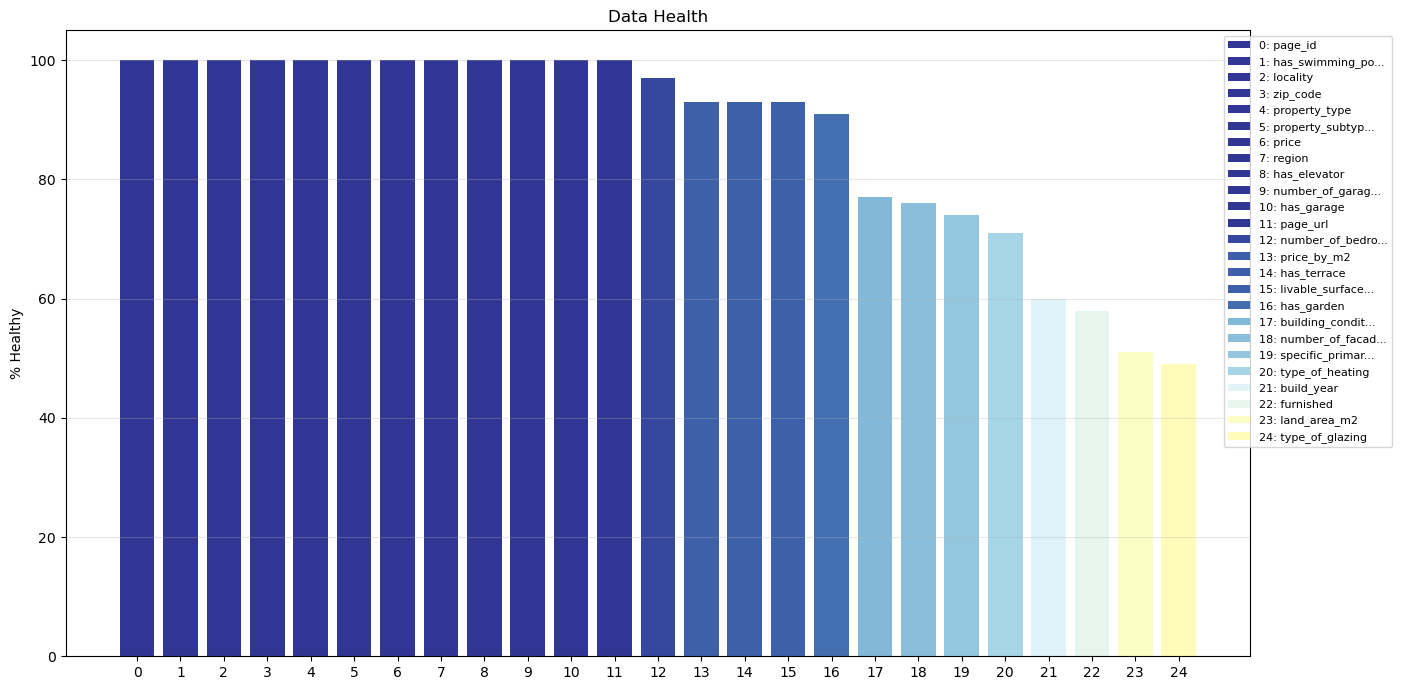

In [42]:
## Visualizing health_data
data_health = (100-(df.isna().mean()*100)).round().sort_values(ascending=False)

## Working on colors:
cmap = plt.get_cmap('RdYlBu') # get the colormap into a variable.
norm = plt.Normalize(vmin=0, vmax=100) # normalise the values for the colormap
colors = cmap(norm(data_health.values)) # sets colors as the color map, on the normalise values, on the values

## Setting the stage of the graph.
fig, ax = plt.subplots(figsize=(14,7),)
labels = [label[:15]+"..." if len(label) > 15 else label for label in data_health.index]
labels_num = list(range(len(data_health.index)))
legends = []
for i in range(len(labels)):
    legends.append(f"{i}: {labels[i]}")

    


### Building the graph
bars = ax.bar(data_health.index, data_health.values, color=colors ) #color='coolwarm' # color="plasma"
ax.set_title("Data Health")
ax.set_ylabel("% Healthy")
ax.grid(True, alpha=0.3, axis="y")
ax.set_xticks(range(len(data_health.index)))
ax.set_xticklabels(labels_num)
ax.legend(bars, legends, loc="upper right", bbox_to_anchor=(1.125, 1), fontsize=8, frameon=True)

plt.xticks()
plt.tight_layout()
plt.show()

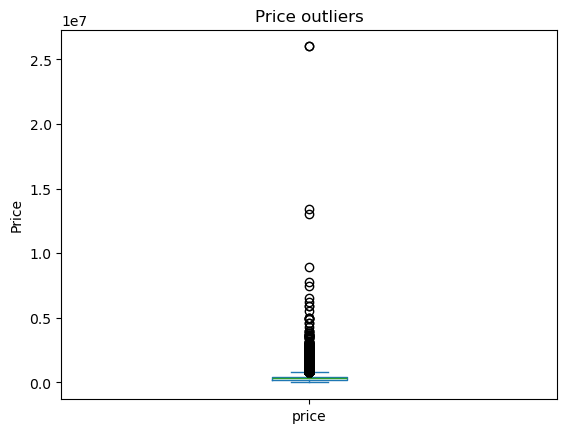

In [43]:
## Looking at outliers:


df['price'].plot.box()
plt.ylabel('Price')
plt.title('Price outliers')
plt.show()


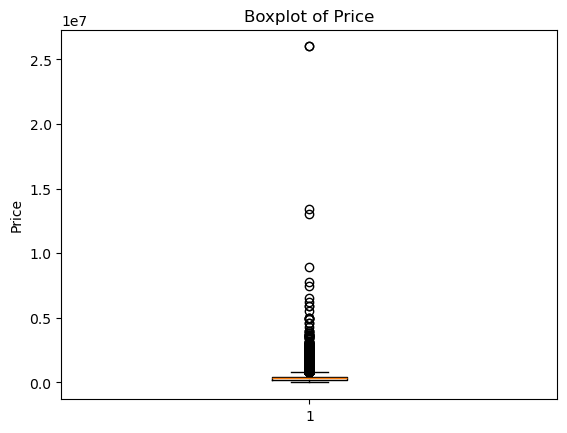

In [50]:
plt.boxplot(df['price'])
plt.ylabel('Price')
plt.title('Boxplot of Price')
plt.show()

In [ ]:
## Basic Distributions#





np.int64(0)

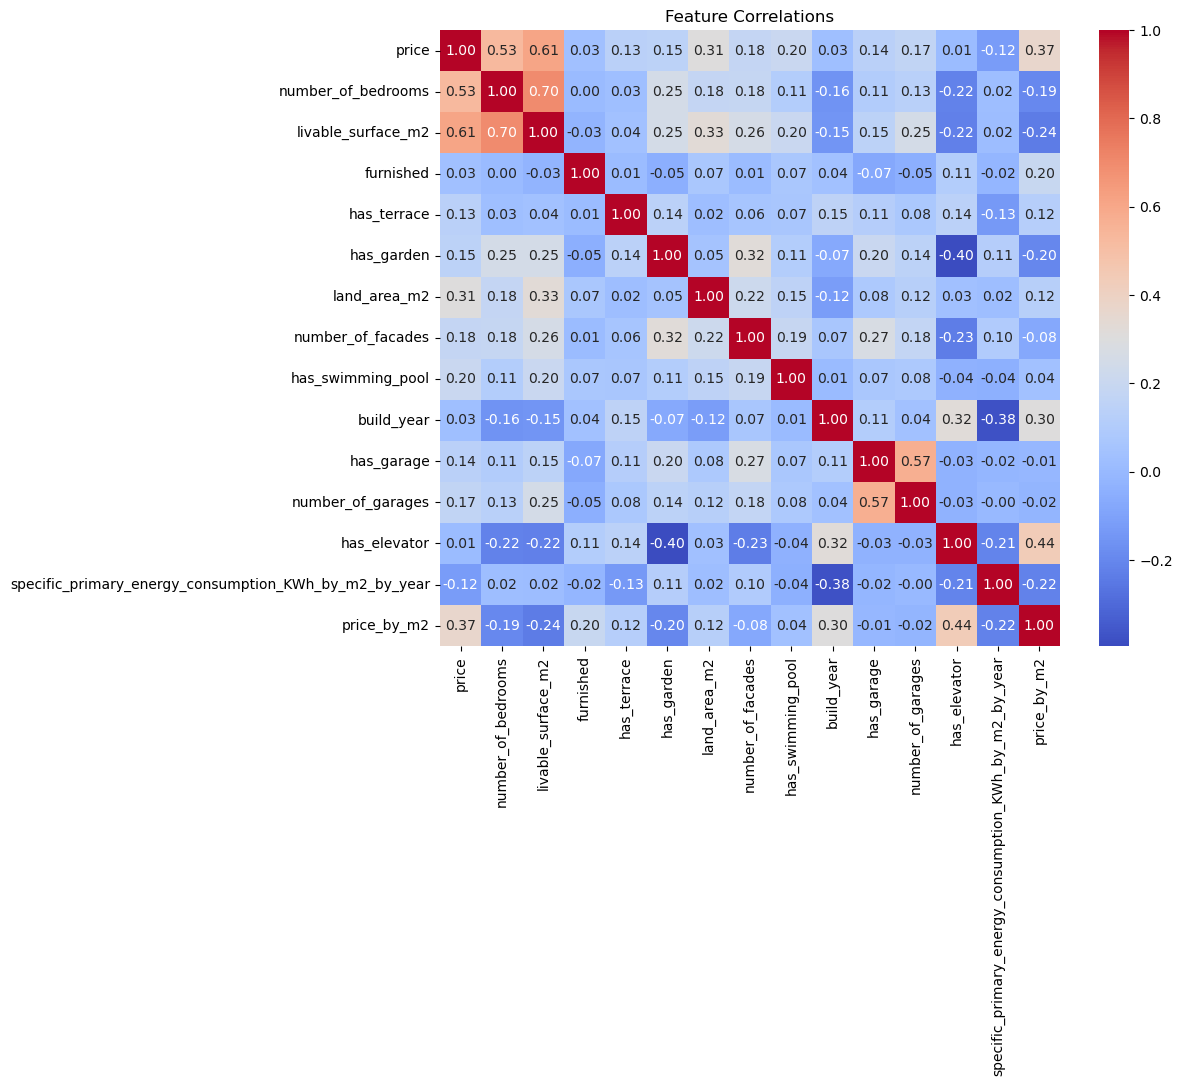

In [54]:
## Correlations
corr_matrix = df.corr(numeric_only=True)
#print(corr_matrix.sort_values)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlations")
plt.show()
